# First Gan

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
from torchvision import transforms
from torchvision.datasets import MNIST
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

### Generator

In [2]:
def get_generator_block(input_dim,output_dim):
  return nn.Sequential(
      nn.Linear(input_dim,output_dim),
      nn.BatchNorm1d(output_dim),
      nn.ReLU(inplace=True)
  )

In [10]:
class Generator(nn.Module):
  def __init__(self,z_dim=10,im_dim=784,hidden_dim=128):
    super().__init__()

    self.gen=nn.Sequential(
        get_generator_block(z_dim,hidden_dim),
        get_generator_block(hidden_dim,hidden_dim*2),
        get_generator_block(hidden_dim*2,hidden_dim*4),
        get_generator_block(hidden_dim*4,hidden_dim*8),

        nn.Linear(hidden_dim*8,im_dim),
        nn.Sigmoid()
    )

  def forward(self,noise):
    return self.gen(noise)


### Noise

In [4]:
def get_noise(n_samples,z_dim,device='cpu'):
  return torch.randn(n_samples,z_dim,device=device)

### Discriminator

In [5]:
def get_discriminator_block(input_dim,output_dim):
  return nn.Sequential(
      nn.Linear(input_dim,output_dim),
      nn.LeakyReLU(0.2,inplace=True)
  )

In [6]:
class Discriminator(nn.Module):
  def __init__(self,im_dim=784,hidden_dim=128):
    super().__init__()

    self.dis=nn.Sequential(
        get_discriminator_block(im_dim,hidden_dim*4),
        get_discriminator_block(hidden_dim*4,hidden_dim*2),
        get_discriminator_block(hidden_dim*2,hidden_dim),
        nn.Linear(hidden_dim,1)
    )

  def forward(self,image):
    return self.dis(image)

### Loss

In [7]:
criterion=nn.BCEWithLogitsLoss()

### Optimizer

In [8]:
z_dim = 64
lr = 0.00001
device = 'cuda'

In [11]:
gen = Generator(z_dim).to(device)
gen_opt = torch.optim.Adam(gen.parameters(), lr=lr)
disc = Discriminator().to(device)
disc_opt = torch.optim.Adam(disc.parameters(), lr=lr)

### Training

In [13]:
n_epochs = 200
display_step = 500
batch_size = 128
# Load MNIST dataset as tensors
dataloader = DataLoader(
    MNIST('.', download=True, transform=transforms.ToTensor()),
    batch_size=batch_size,
    shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 474kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.01MB/s]


In [14]:
def get_disc_loss(gen,disc,criterion,real,num_images,z_dim,device):

  fake_noise=get_noise(num_images,z_dim,device=device)
  fake_images=gen(fake_noise)

  disc_fake_pred=disc(fake_images.detach())
  disc_fake_loss=criterion(disc_fake_pred,torch.zeros_like(disc_fake_pred))

  disc_real_pred=disc(real)
  disc_real_loss=criterion(disc_real_pred,torch.ones_like(disc_real_pred))

  disc_loss=(disc_fake_loss+disc_real_loss)/2
  return disc_loss



In [15]:
def get_gen_loss(gen, disc, criterion, num_images, z_dim, device):
    fake_noise = get_noise(num_images, z_dim, device=device)
    fake_images = gen(fake_noise)
    disc_fake_pred = disc(fake_images)
    gen_loss = criterion(disc_fake_pred, torch.ones_like(disc_fake_pred))
    return gen_loss

Epoch: 20, Generator Loss: 0.9935, Discriminator Loss: 0.5704


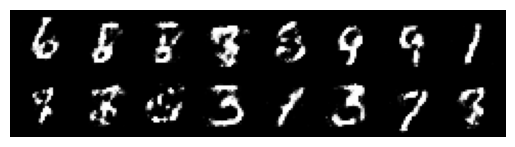

Epoch: 40, Generator Loss: 0.9493, Discriminator Loss: 0.5871


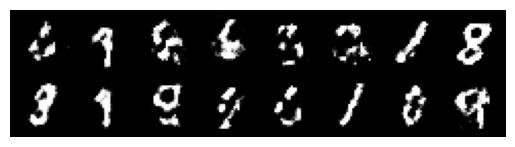

Epoch: 60, Generator Loss: 0.9191, Discriminator Loss: 0.6000


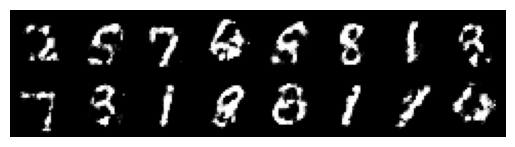

Epoch: 80, Generator Loss: 0.9033, Discriminator Loss: 0.5939


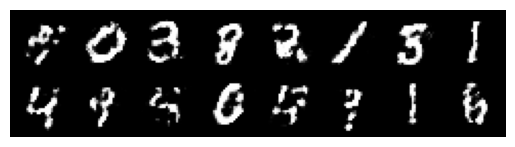

Epoch: 100, Generator Loss: 0.8366, Discriminator Loss: 0.6317


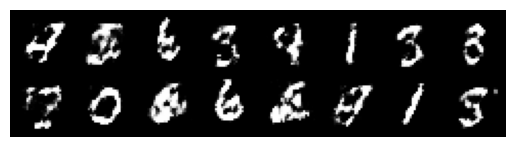

Epoch: 120, Generator Loss: 0.8929, Discriminator Loss: 0.5874


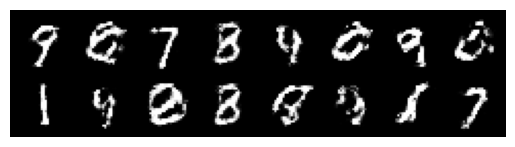

Epoch: 140, Generator Loss: 0.8347, Discriminator Loss: 0.6322


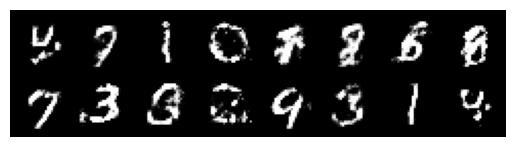

Epoch: 160, Generator Loss: 0.8777, Discriminator Loss: 0.6037


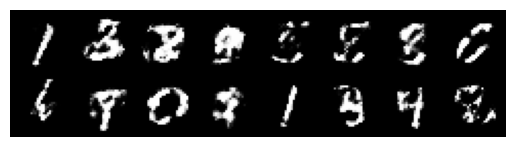

Epoch: 180, Generator Loss: 0.9241, Discriminator Loss: 0.5831


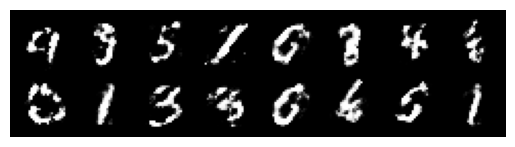

Epoch: 200, Generator Loss: 0.8618, Discriminator Loss: 0.6095


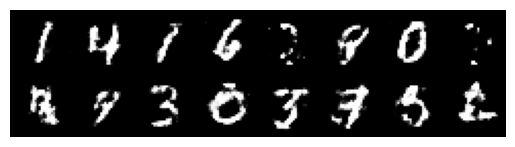

In [19]:
generator_loss = 0
discriminator_loss = 0

for epoch in range(n_epochs):
    generator_loss = 0
    discriminator_loss = 0

    for real, _ in dataloader:
        cur_batch_size = len(real)
        real = real.view(cur_batch_size, -1).to(device)

        # Discriminator update
        disc_opt.zero_grad()
        disc_loss = get_disc_loss(gen, disc, criterion, real, cur_batch_size, z_dim, device)
        disc_loss.backward()
        disc_opt.step()

        # Generator update
        gen_opt.zero_grad()
        gen_loss = get_gen_loss(gen, disc, criterion, cur_batch_size, z_dim, device)
        gen_loss.backward()
        gen_opt.step()

        generator_loss += gen_loss.item() / len(dataloader)
        discriminator_loss += disc_loss.item() / len(dataloader)

    # Display every 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f"Epoch: {epoch + 1}, Generator Loss: {generator_loss:.4f}, Discriminator Loss: {discriminator_loss:.4f}")
        fake_noise = get_noise(16, z_dim, device=device)
        fake_images = gen(fake_noise)
        fake_images = fake_images.view(16, 1, 28, 28)  # <- fixed here

        grid = make_grid(fake_images, nrow=8)
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.axis("off")
        plt.show()
